In [1]:
!pip install jamo jamotools jiwer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.3 MB/s eta 0:00:00


In [2]:
import torch
import os
import pandas as pd
import torchaudio
import jamotools
from jamo import h2j, j2hcj
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from transformers import (
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
    TrainingArguments,
    Trainer,
    TrainerCallback
)
from google.colab import drive
import shutil
from tqdm.auto import tqdm

drive.mount('/content/drive')

print(f"✅ GPU Active: {torch.cuda.is_available()}")
print(f"🖥️ Device: {torch.cuda.get_device_name(0)}")

# Paths
AUDIO_DIR  = "/content/drive/MyDrive/manual_datasets/clovacall_data/wavs_resampled_16k/"
TRAIN_JSON = "/content/drive/MyDrive/manual_datasets/clovacall_data/train_ClovaCall.json"
VOCAB_PATH = "/content/drive/MyDrive/manual_datasets/clovacall_data/jamo_vocab.json"
SAVE_DIR   = "/content/drive/MyDrive/manual_datasets/clovacall_data/final_asr_v2_model"
RESULTS_DIR = "/content/drive/MyDrive/manual_datasets/clovacall_data/asr_v2_results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ Paths set")

Mounted at /content/drive
✅ GPU Active: True
🖥️ Device: Tesla T4
✅ Paths set


In [3]:
# Load only train JSON (resampled wavs only)
train_df_full = pd.read_json(TRAIN_JSON)

# Split into train / val / test
train_df, temp_df = train_test_split(train_df_full, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

# Use 20k training samples and 1k validation
train_subset = train_df.sample(n=20000, random_state=42)
val_subset   = val_df.sample(n=1000, random_state=42)

print(f"✅ Train samples: {len(train_subset)}")
print(f"✅ Val samples:   {len(val_subset)}")

✅ Train samples: 20000
✅ Val samples:   1000


In [5]:
# Load Jamo tokenizer
tokenizer = Wav2Vec2CTCTokenizer(
    VOCAB_PATH,
    unk_token="[UNK]",
    pad_token="[PAD]",
    word_delimiter_token="|"
)

# Load feature extractor from facebook/wav2vec2-base
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)

# Load model from facebook/wav2vec2-base
model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base",
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
    ignore_mismatched_sizes=True
)

# ── Architectural changes ──────────────────────────────────────
# 1. Freeze CNN feature extractor — already well trained on speech
model.wav2vec2.feature_extractor._freeze_parameters()

# 2. Dropout regularization
model.config.final_dropout    = 0.1
model.config.hidden_dropout   = 0.1
model.config.feat_proj_dropout = 0.1
model.config.attention_dropout = 0.1

# 3. Layer drop — randomly drops transformer layers during training
model.config.layerdrop = 0.1

model = model.to("cuda")

print(f"✅ Model loaded: facebook/wav2vec2-base")
print(f"📦 Vocab size: {len(processor.tokenizer)}")
print(f"🔒 Feature extractor frozen")
print(f"📊 Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
lm_head.bias                 | MISSING    | 
lm_head.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: facebook/wav2vec2-base
📦 Vocab size: 82
🔒 Feature extractor frozen
📊 Trainable parameters: 90,234,322


In [7]:
import concurrent.futures
import shutil
import os
from tqdm.auto import tqdm

LOCAL_WAV_DIR = "/content/local_wavs/"
os.makedirs(LOCAL_WAV_DIR, exist_ok=True)

files_to_copy = list(set(train_subset['wav'].tolist() + val_subset['wav'].tolist()))

def copy_file(f):
    src = os.path.join(AUDIO_DIR, f)
    dst = os.path.join(LOCAL_WAV_DIR, f)
    try:
        shutil.copy(src, dst)
        return "copied"
    except (OSError, FileNotFoundError):
        return "skipped"

print("🚀 Localizing audio to SSD (parallel)...")
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(copy_file, files_to_copy), total=len(files_to_copy), desc="Copying"))

copied  = results.count("copied")
skipped = results.count("skipped")
print(f"✅ Copied: {copied} | Skipped: {skipped}")

🚀 Localizing audio to SSD (parallel)...


Copying:   0%|          | 0/21000 [00:00<?, ?it/s]

✅ Copied: 21000 | Skipped: 0


In [8]:
class JamoASRDataset(Dataset):
    def __init__(self, df, processor, audio_dir):
        self.df        = df
        self.processor = processor
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        wav_path = os.path.join(self.audio_dir, self.df.iloc[idx]['wav'])
        try:
            speech, _ = torchaudio.load(wav_path)
        except Exception:
            speech = torch.zeros(1, 16000)

        input_values = self.processor(
            speech.squeeze().numpy(),
            sampling_rate=16000
        ).input_values[0]

        jamo_text = j2hcj(h2j(self.df.iloc[idx]['text']))
        labels    = self.processor(text=jamo_text).input_ids

        return {"input_values": input_values, "labels": labels}

@dataclass
class DataCollatorCTCWithPadding:
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features):
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.feature_extractor.pad(
            input_features, padding=self.padding, return_tensors="pt"
        )
        labels_batch = self.processor.tokenizer.pad(
            label_features, padding=self.padding, return_tensors="pt"
        )
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        batch["labels"] = labels
        return batch

train_dataset  = JamoASRDataset(train_subset, processor, LOCAL_WAV_DIR)
val_dataset    = JamoASRDataset(val_subset, processor, LOCAL_WAV_DIR)
data_collator  = DataCollatorCTCWithPadding(processor=processor, padding=True)

print(f"✅ Train dataset: {len(train_dataset)} samples")
print(f"✅ Val dataset:   {len(val_dataset)} samples")

✅ Train dataset: 20000 samples
✅ Val dataset:   1000 samples


In [9]:
class VisualProgressCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            print(f"✅ Step {state.global_step}: Loss = {logs['loss']:.4f}")

training_args = TrainingArguments(
    output_dir=RESULTS_DIR,
    group_by_length=False,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=10,
    fp16=True,
    learning_rate=1e-4,
    warmup_steps=200,
    eval_strategy="steps",       # ← validation loss during training
    eval_steps=500,
    save_steps=500,
    save_total_limit=2,
    logging_steps=10,
    dataloader_num_workers=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=processor,
    callbacks=[VisualProgressCallback()]
)

print("✅ Trainer ready")
print(f"📊 Effective batch size: {8 * 4}")
print(f"📊 Total training steps: {len(train_dataset) // (8 * 4) * 10}")

✅ Trainer ready
📊 Effective batch size: 32
📊 Total training steps: 6250


In [10]:
print("🚀 Training ASR v2...")
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 81, 'bos_token_id': 80}.


🚀 Training ASR v2...


Step,Training Loss,Validation Loss
500,8.992912,1.888721
1000,2.690491,0.510180
1500,2.178289,0.371828
2000,1.647752,0.316002
2500,1.497506,0.285022
3000,1.196439,0.259815
3500,1.018116,0.242408
4000,0.989062,0.231920
4500,1.146703,0.213810
5000,1.035698,0.205196


✅ Step 10: Loss = 132.1998
✅ Step 20: Loss = 119.2087
✅ Step 30: Loss = 96.4535
✅ Step 40: Loss = 69.1803
✅ Step 50: Loss = 37.8135
✅ Step 60: Loss = 31.4962
✅ Step 70: Loss = 24.8781
✅ Step 80: Loss = 24.2399
✅ Step 90: Loss = 21.4694
✅ Step 100: Loss = 19.7872
✅ Step 110: Loss = 17.3742
✅ Step 120: Loss = 16.7106
✅ Step 130: Loss = 15.4754
✅ Step 140: Loss = 16.0881
✅ Step 150: Loss = 15.5154
✅ Step 160: Loss = 14.4320
✅ Step 170: Loss = 14.0296
✅ Step 180: Loss = 13.4523
✅ Step 190: Loss = 13.4582
✅ Step 200: Loss = 13.4542
✅ Step 210: Loss = 13.8265
✅ Step 220: Loss = 14.3542
✅ Step 230: Loss = 13.2395
✅ Step 240: Loss = 13.2088
✅ Step 250: Loss = 13.0552
✅ Step 260: Loss = 12.8862
✅ Step 270: Loss = 13.0000
✅ Step 280: Loss = 12.7890
✅ Step 290: Loss = 12.9663
✅ Step 300: Loss = 12.6785
✅ Step 310: Loss = 12.6353
✅ Step 320: Loss = 12.6269
✅ Step 330: Loss = 12.6205
✅ Step 340: Loss = 12.4872
✅ Step 350: Loss = 12.5774
✅ Step 360: Loss = 12.4874
✅ Step 370: Loss = 12.5441
✅ Step 3

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

✅ Step 5510: Loss = 0.9176
✅ Step 5520: Loss = 0.9506
✅ Step 5530: Loss = 1.0385
✅ Step 5540: Loss = 0.6931
✅ Step 5550: Loss = 0.9134
✅ Step 5560: Loss = 0.8415
✅ Step 5570: Loss = 0.9028
✅ Step 5580: Loss = 0.9616
✅ Step 5590: Loss = 0.9032
✅ Step 5600: Loss = 0.8091
✅ Step 5610: Loss = 0.9744
✅ Step 5620: Loss = 0.8249
✅ Step 5630: Loss = 0.7767
✅ Step 5640: Loss = 0.7537
✅ Step 5650: Loss = 0.8626
✅ Step 5660: Loss = 0.9756
✅ Step 5670: Loss = 0.8488
✅ Step 5680: Loss = 0.7752
✅ Step 5690: Loss = 0.8370
✅ Step 5700: Loss = 0.9976
✅ Step 5710: Loss = 0.8688
✅ Step 5720: Loss = 0.8661
✅ Step 5730: Loss = 0.9565
✅ Step 5740: Loss = 0.8642
✅ Step 5750: Loss = 0.9079
✅ Step 5760: Loss = 0.9805
✅ Step 5770: Loss = 1.0511
✅ Step 5780: Loss = 0.8163
✅ Step 5790: Loss = 0.8435
✅ Step 5800: Loss = 0.9043
✅ Step 5810: Loss = 0.8014
✅ Step 5820: Loss = 1.0701
✅ Step 5830: Loss = 0.9084
✅ Step 5840: Loss = 0.8145
✅ Step 5850: Loss = 0.8692
✅ Step 5860: Loss = 0.9118
✅ Step 5870: Loss = 0.7852
✅

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Step 6010: Loss = 0.9170
✅ Step 6020: Loss = 0.8923
✅ Step 6030: Loss = 0.8570
✅ Step 6040: Loss = 0.8389
✅ Step 6050: Loss = 0.8162
✅ Step 6060: Loss = 0.9479
✅ Step 6070: Loss = 1.0145
✅ Step 6080: Loss = 0.8722
✅ Step 6090: Loss = 0.7769
✅ Step 6100: Loss = 0.8344
✅ Step 6110: Loss = 0.7591
✅ Step 6120: Loss = 0.8770
✅ Step 6130: Loss = 0.7676
✅ Step 6140: Loss = 0.9172
✅ Step 6150: Loss = 0.8788
✅ Step 6160: Loss = 0.9629
✅ Step 6170: Loss = 0.8500
✅ Step 6180: Loss = 0.8038
✅ Step 6190: Loss = 0.8281
✅ Step 6200: Loss = 0.7364
✅ Step 6210: Loss = 0.8837
✅ Step 6220: Loss = 0.7649
✅ Step 6230: Loss = 0.7586
✅ Step 6240: Loss = 0.7724
✅ Step 6250: Loss = 0.9483


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6250, training_loss=3.222023861618042, metrics={'train_runtime': 6299.246, 'train_samples_per_second': 31.75, 'train_steps_per_second': 0.992, 'total_flos': 9.85488328124814e+18, 'train_loss': 3.222023861618042, 'epoch': 10.0})

In [11]:
trainer.save_model(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)
feature_extractor.save_pretrained(SAVE_DIR)  # fixes preprocessor_config.json issue

print(f"✅ Model saved to: {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: /content/drive/MyDrive/manual_datasets/clovacall_data/final_asr_v2_model


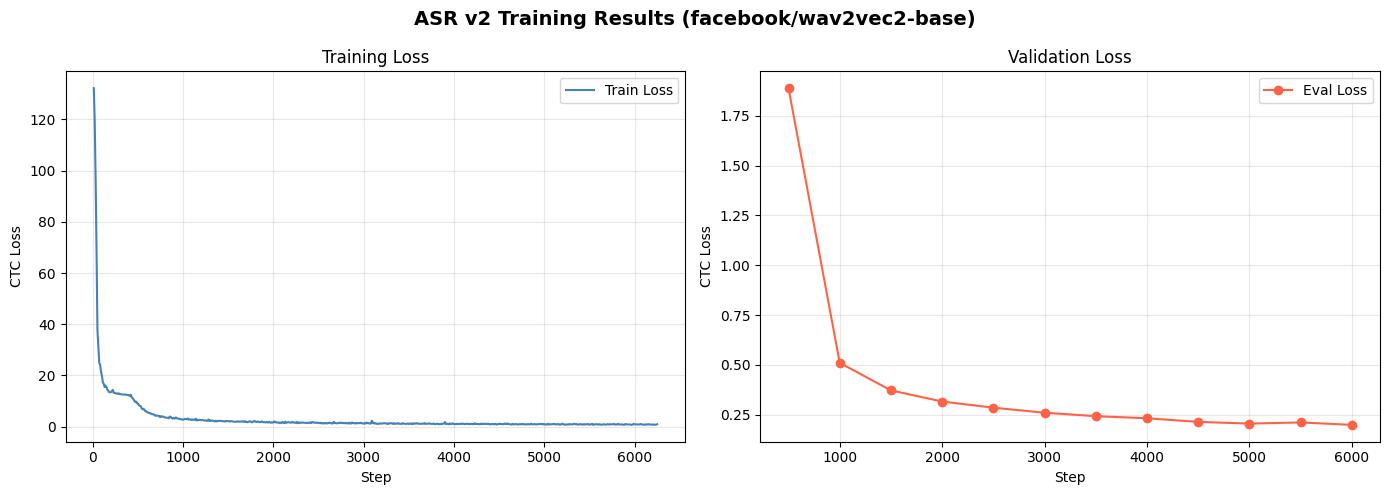

✅ Plots saved


In [12]:
import json
import matplotlib.pyplot as plt

log_history  = trainer.state.log_history
train_logs   = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs    = [l for l in log_history if "eval_loss" in l]

train_steps  = [l["step"] for l in train_logs]
train_losses = [l["loss"] for l in train_logs]
eval_steps   = [l["step"] for l in eval_logs]
eval_losses  = [l["eval_loss"] for l in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ASR v2 Training Results (facebook/wav2vec2-base)", fontsize=14, fontweight="bold")

axes[0].plot(train_steps, train_losses, color="steelblue", linewidth=1.5, label="Train Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("CTC Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if eval_logs:
    axes[1].plot(eval_steps, eval_losses, color="tomato", linewidth=1.5, marker="o", label="Eval Loss")
    axes[1].set_title("Validation Loss")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("CTC Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "asr_v2_training_plots.png"), dpi=300, bbox_inches="tight")
plt.show()
print("✅ Plots saved")

In [13]:
from jiwer import cer

def calculate_global_per(model, dataset, processor):
    model.eval()
    refs  = []
    preds = []

    for i in tqdm(range(len(dataset)), desc="Calculating PER"):
        sample       = dataset[i]
        input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to("cuda")

        ref_jamo = processor.decode(
            sample["labels"], group_tokens=False
        ).replace("[PAD]", "").replace("|", " ").strip()
        refs.append(ref_jamo)

        with torch.no_grad():
            logits = model(input_values).logits
        pred_ids = torch.argmax(logits, dim=-1)
        pred_jamo = processor.batch_decode(pred_ids)[0]
        preds.append(pred_jamo)

    global_per = cer(refs, preds)

    print(f"\n✨ --- ASR v2 RESULTS --- ✨")
    print(f"📊 Samples evaluated: {len(refs)}")
    print(f"📊 Global PER:        {global_per * 100:.2f}%")
    print(f"✅ Accuracy:          {(1 - global_per) * 100:.2f}%")
    return global_per

global_per = calculate_global_per(model, val_dataset, processor)

Calculating PER:   0%|          | 0/1000 [00:00<?, ?it/s]


✨ --- ASR v2 RESULTS --- ✨
📊 Samples evaluated: 1000
📊 Global PER:        5.30%
✅ Accuracy:          94.70%
